# Confronto Auto Elettriche vs Ibride in Italia (2015-2023)

Analisi della distribuzione di autovetture elettriche e ibride per 1.000 autovetture nei comuni capoluogo italiani.

## 1. Importazione librerie e caricamento dati

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configurazione per grafici ad alta risoluzione
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

In [33]:
# Caricamento dei dati
# NOTA: index_col=False è necessario per leggere correttamente questi CSV ISTAT
df_elettriche = pd.read_csv('../data/csv/auto_elettr_su_1000.csv',
                             encoding='utf-8-sig',
                             index_col=False)

df_ibride = pd.read_csv('../data/csv/auto_ibride_su_1000.csv',
                        encoding='utf-8-sig',
                        index_col=False)

## 3. Preparazione dati per l'Italia

In [34]:
# Filtro solo i dati nazionali (REF_AREA == 'IT' corrisponde a Italia)
df_elettriche_it = df_elettriche[df_elettriche['REF_AREA'] == 'IT'].copy()
df_ibride_it = df_ibride[df_ibride['REF_AREA'] == 'IT'].copy()

In [35]:
# Seleziono e rinomino le colonne necessarie
df_elettriche_it = df_elettriche_it[['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Elettriche'}
)

df_ibride_it = df_ibride_it[['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Ibride'}
)

In [36]:
# Merge dei due dataset
df_merged = pd.merge(df_elettriche_it, df_ibride_it, on='Anno')

# Conversione a numerico
df_merged['Elettriche'] = pd.to_numeric(df_merged['Elettriche'], errors='coerce')
df_merged['Ibride'] = pd.to_numeric(df_merged['Ibride'], errors='coerce')

# Rimuovo eventuali valori mancanti
df_merged = df_merged.dropna()

## 4. Analisi descrittiva

In [37]:
# Calcolo statistiche base
df_merged['Totale'] = df_merged['Elettriche'] + df_merged['Ibride']
df_merged['Perc_Elettriche'] = (df_merged['Elettriche'] / df_merged['Totale'] * 100).round(1)
df_merged['Perc_Ibride'] = (df_merged['Ibride'] / df_merged['Totale'] * 100).round(1)

## 6. Visualizzazione: Evoluzione Temporale

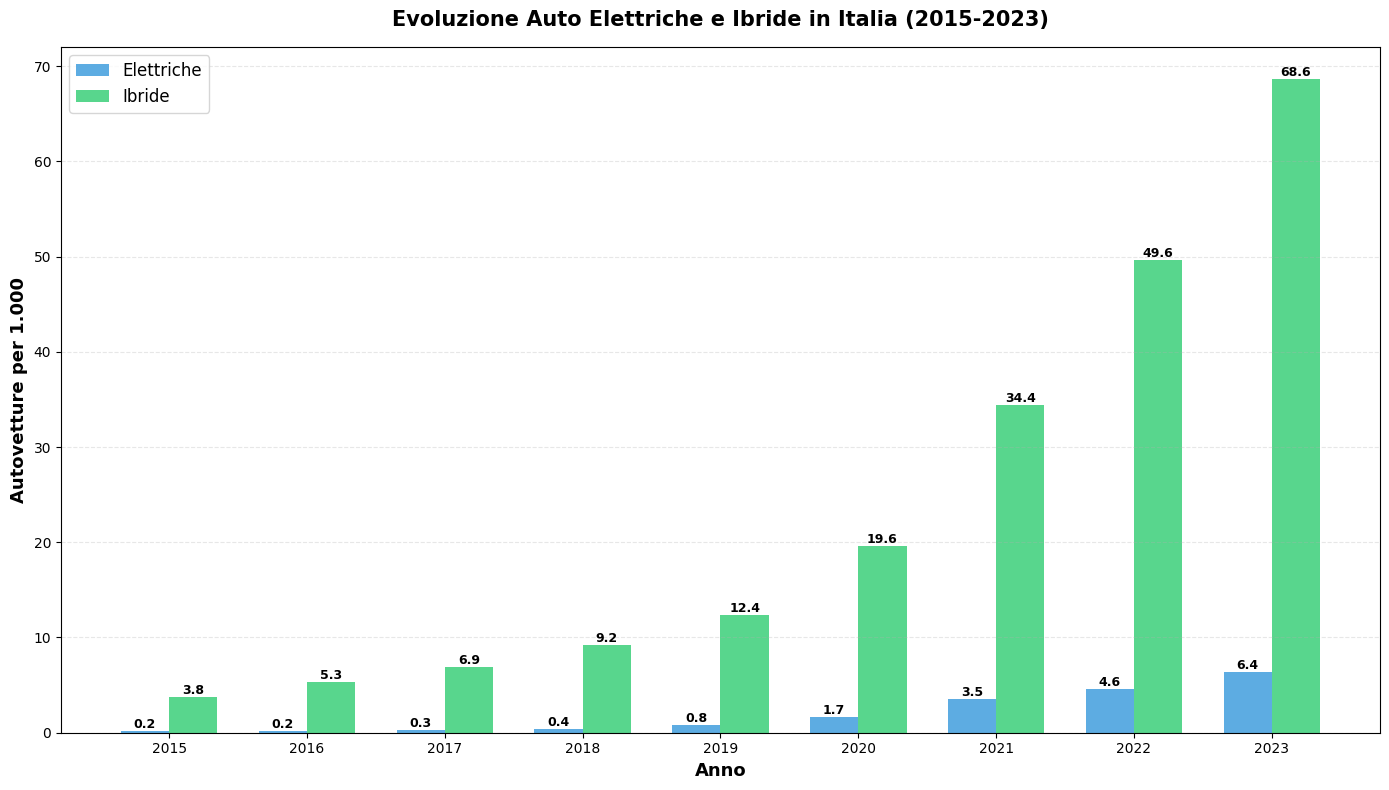

✓ Grafico evoluzione temporale salvato


In [38]:
anni = sorted(df_merged['Anno'].unique())
n_anni = len(anni)

# Grafico a barre per l'evoluzione temporale
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(anni))
width = 0.35

bars1 = ax.bar(x - width/2, df_merged['Elettriche'], width, 
                label='Elettriche', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, df_merged['Ibride'], width,
                label='Ibride', color='#2ecc71', alpha=0.8)

# Aggiungo i valori sopra le barre
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Anno', fontsize=13, fontweight='bold')
ax.set_ylabel('Autovetture per 1.000', fontsize=13, fontweight='bold')
ax.set_title('Evoluzione Auto Elettriche e Ibride in Italia (2015-2023)', 
              fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(anni)
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('evoluzione_elettriche_ibride.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico evoluzione temporale salvato")

## 7. Analisi dei trend

In [39]:
# Calcolo tassi di crescita anno su anno
df_merged_sorted = df_merged.sort_values('Anno').reset_index(drop=True)

df_merged_sorted['Crescita_Elettriche_%'] = df_merged_sorted['Elettriche'].pct_change() * 100
df_merged_sorted['Crescita_Ibride_%'] = df_merged_sorted['Ibride'].pct_change() * 100

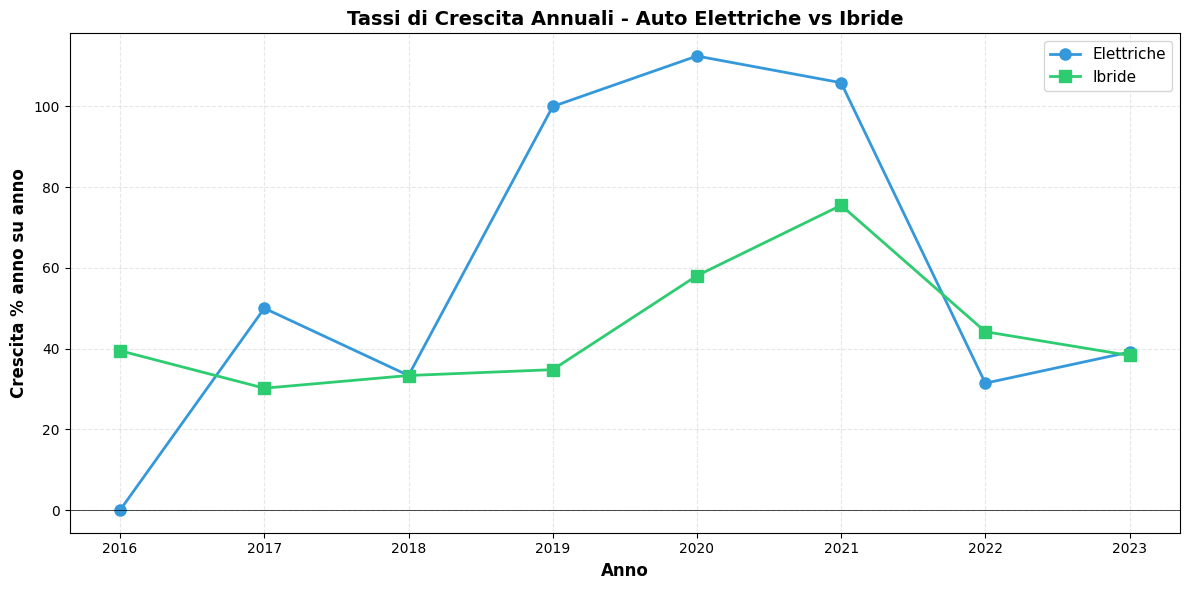

✓ Grafico crescita anno su anno salvato


In [40]:
# Grafico dei tassi di crescita
fig, ax = plt.subplots(figsize=(12, 6))

# Escludo il primo anno (NaN)
df_crescita = df_merged_sorted[1:]

ax.plot(df_crescita['Anno'], df_crescita['Crescita_Elettriche_%'], 
        marker='o', linewidth=2, markersize=8, label='Elettriche', color='#3498db')
ax.plot(df_crescita['Anno'], df_crescita['Crescita_Ibride_%'], 
        marker='s', linewidth=2, markersize=8, label='Ibride', color='#2ecc71')

ax.set_xlabel('Anno', fontsize=12, fontweight='bold')
ax.set_ylabel('Crescita % anno su anno', fontsize=12, fontweight='bold')
ax.set_title('Tassi di Crescita Annuali - Auto Elettriche vs Ibride', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('crescita_anno_su_anno.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Grafico crescita anno su anno salvato")

## 8. Conclusioni

### Principali osservazioni:

1. **Dominanza delle ibride**: Le auto ibride rappresentano il 91-96% del mercato elettrificato italiano
2. **Crescita accelerata**: Entrambe le tipologie mostrano una forte accelerazione dal 2020 in poi
3. **Base di partenza**: Le elettriche partono da valori molto bassi (0.2 per 1000 nel 2015) ma crescono rapidamente
4. **Trend recente**: Dal 2020 al 2023, le auto ibride sono cresciute da 19.6 a 68.6 per 1000 (+250%)
5. **Elettriche in crescita**: Le auto elettriche sono passate da 1.7 a 6.4 per 1000 (+276%) nello stesso periodo